In [ ]:
import serial
import time
import numpy as np

distances = [1, 2, 3, 4, 5] # cm
voltages = []

with serial.Serial("COM4", 115200, timeout=2) as arduino:
    time.sleep(2)

    for distance in distances:
        input(f"Move to {distance} cm, then press Enter: ")
        arduino.reset_input_buffer()
        arduino.readline()

        readings = [float(arduino.readline()) for _ in range(20)]
        voltage = sum(readings) / len(readings) * 5.0 / 1023
        voltages.append(voltage)
        print(round(voltage, 4), "V")

table = pd.DataFrame({"Distance (cm)": distances,"Voltage (V)": voltages})
slope = np.polyfit(distances, voltages, 1)[0]

if np.isclose(slope, 0):
    direction = "flat"
elif slope < 0:
    direction = "Positive"
else:
    direction = "Negative"

filename = f"distance_voltage_{direction}.csv"
table.to_csv(filename, index=False)

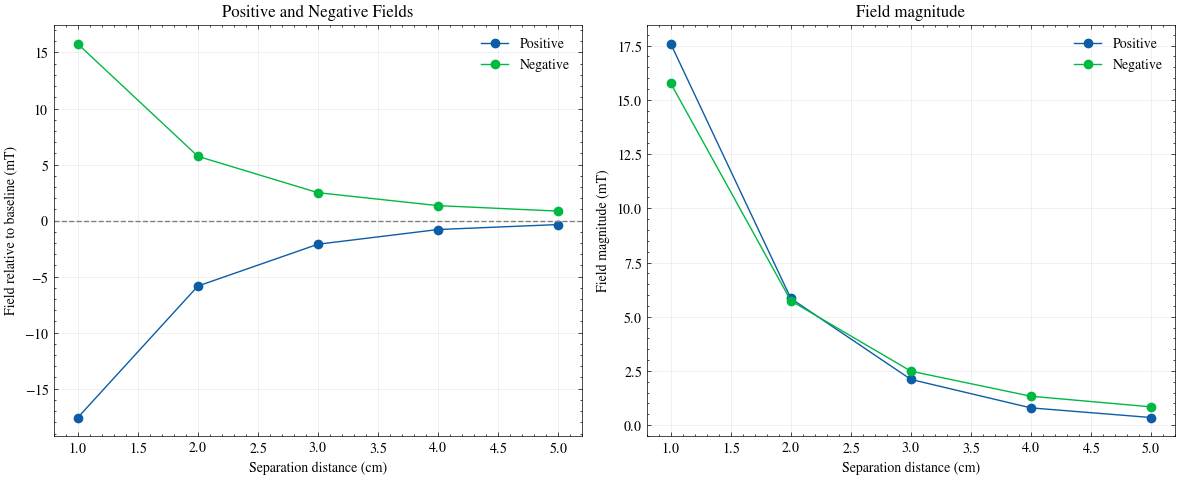

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(["science", "no-latex"])

positive = pd.read_csv("distance_voltage_Positive.csv")
negative = pd.read_csv("distance_voltage_Negative.csv")

baseline = 0.99       # V
sensitivity = -0.011  # V/mT

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for data, label in [(positive, "Positive"), (negative, "Negative")]:
    data = data.sort_values("Distance (cm)")
    distance = data["Distance (cm)"]
    field = (data["Voltage (V)"] - baseline) / sensitivity

    axes[0].plot(distance, field, "o-", label=label)
    axes[1].plot(distance, field.abs(), "o-", label=label)

axes[0].set_title("Positive and Negative Fields")
axes[0].set_ylabel("Field relative to baseline (mT)")
axes[0].axhline(0, color="gray", linestyle="--", linewidth=1)

axes[1].set_title("Field magnitude")
axes[1].set_ylabel("Field magnitude (mT)")

for ax in axes:
    ax.set_xlabel("Separation distance (cm)")
    ax.legend()
    ax.grid(True, alpha=0.25)

fig.tight_layout()
fig.savefig("magnetic_field_comparison.png", dpi=300)
plt.show()